<a href="https://colab.research.google.com/github/ethereins/ImageProcessing/blob/main/IPTugas2_IndahSyahfitri_2311532016.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
from google.colab import files
uploaded = files.upload()

Saving prabski.jpeg to prabski (2).jpeg


Kode di atas ini berfungsi untuk mengimpor modul files yang tersedia di Google Colab dan digunakan untuk menangani proses unggah atau unduh file. Jadi saat dirun, kita bisa memilih foto yang akan diproses.

(np.float64(-0.5), np.float64(735.5), np.float64(413.5), np.float64(-0.5))

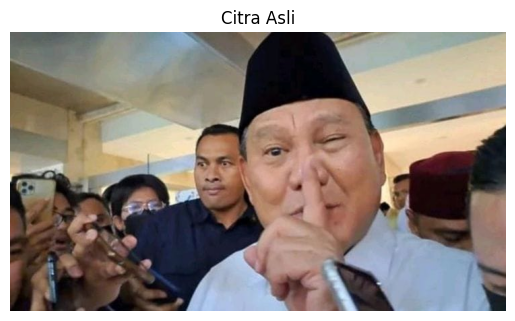

In [76]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('prabski.jpeg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis('off')

Kode tersebut digunakan untuk membaca dan menampilkan citra asli. Library cv2 digunakan untuk membaca citra, numpy untuk operasi array, dan matplotlib untuk menampilkan gambar. Perintah cv2.imread('prabski.jpeg') membaca file citra, kemudian cv2.cvtColor(img, cv2.COLOR_BGR2RGB) mengubah format warna dari BGR ke RGB agar tampil dengan benar saat ditampilkan menggunakan plt.imshow(). Judul gambar ditambahkan dengan plt.title("Citra Asli"), dan plt.axis('off') digunakan untuk menyembunyikan sumbu pada tampilan citra.

(np.float64(-0.5), np.float64(735.5), np.float64(413.5), np.float64(-0.5))

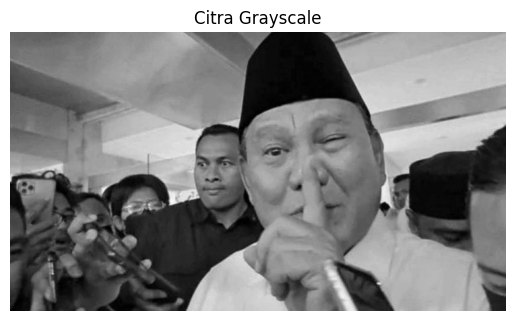

In [99]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
M, N = img_gray.shape

result = np.zeros((M,N), dtype=np.uint8)

for i in range(M):
    for j in range(N):
        value = int(img_gray[i,j])

        if value > 255:
            value = 255
        elif value < 0:
            value = 0

        result[i,j] = value

plt.imshow(img_gray, cmap='gray')
plt.title("Citra Grayscale")
plt.axis('off')

Kode tersebut digunakan untuk mengubah citra menjadi grayscale dan menampilkannya. Perintah cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) mengubah citra berwarna menjadi citra grayscale dan disimpan dalam variabel img_gray. Kemudian ukuran citra diambil dengan M, N = img_gray.shape. Array kosong result dibuat dengan ukuran yang sama untuk menyimpan nilai piksel. Melalui perulangan for, setiap piksel diambil nilainya lalu dicek agar tetap berada pada rentang 0–255.

In [100]:
M, N = img_gray.shape
total_pixel = M * N

Kode tersebut digunakan untuk mengetahui ukuran citra dan menghitung jumlah total piksel. Perintah M, N = img_gray.shape mengambil dimensi citra grayscale, di mana M adalah jumlah baris (tinggi citra) dan N adalah jumlah kolom (lebar citra). Selanjutnya total_pixel = M * N menghitung total seluruh piksel dalam citra dengan mengalikan jumlah baris dan kolom.

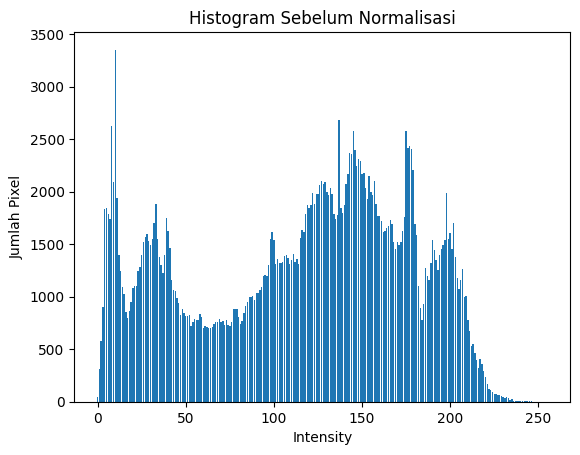

In [79]:
hist_before = np.zeros(256)

for i in range(M):
    for j in range(N):
        intensity = img_gray[i,j]
        hist_before[intensity] += 1

plt.figure()
plt.title("Histogram Sebelum Normalisasi")
plt.bar(range(256), hist_before)
plt.xlabel("Intensity")
plt.ylabel("Jumlah Pixel")
plt.show()

Kode tersebut digunakan untuk menghitung dan menampilkan histogram citra grayscale sebelum normalisasi. Array hist_before = np.zeros(256) dibuat untuk menyimpan jumlah piksel pada setiap tingkat intensitas (0–255). Melalui perulangan for, setiap piksel pada citra img_gray diambil nilai intensitasnya lalu jumlahnya ditambahkan ke indeks histogram yang sesuai.

In [89]:
min_val = np.min(img_gray)
max_val = np.max(img_gray)

print(f"Min intensity of original grayscale image: {min_val}")
print(f"Max intensity of original grayscale image: {max_val}")

Min intensity of original grayscale image: 0
Max intensity of original grayscale image: 251


Kode tersebut digunakan untuk menentukan nilai intensitas minimum dan maksimum pada citra grayscale. Fungsi np.min(img_gray) digunakan untuk mencari nilai piksel paling kecil, sedangkan np.max(img_gray) untuk mencari nilai piksel paling besar pada citra. Ini juga bisa digunakan untuk melihat perubahan sebelum dan sesudah normalisasi nantinya.

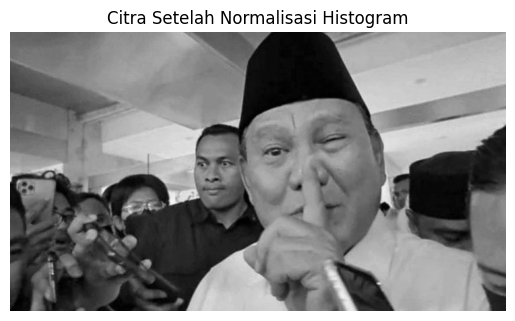

In [111]:
img_norm = np.zeros((M,N), dtype=np.uint8)

if (max_val - min_val) == 0:
    pass
else:
    for i in range(M):
        for j in range(N):
            # Convert to float64 for calculation to prevent overflow, then cast back to uint8
            img_norm[i,j] = ((img_gray[i,j].astype(np.float64) - min_val) * 255 / (max_val - min_val)).astype(np.uint8)

plt.figure()
plt.imshow(img_norm, cmap='gray')
plt.title("Citra Setelah Normalisasi Histogram")
plt.axis('off')
plt.show()

Kode tersebut digunakan untuk melakukan normalisasi intensitas pada citra grayscale. Pertama dibuat array kosong img_norm dengan ukuran yang sama seperti citra grayscale untuk menyimpan hasil normalisasi. Kemudian dicek apakah (max_val - min_val) bernilai 0 untuk menghindari pembagian dengan nol. Jika tidak, setiap piksel pada img_gray dihitung ulang menggunakan rumus normalisasi agar rentang intensitasnya menjadi 0–255. Perhitungan dilakukan dalam tipe float64 untuk mencegah overflow, lalu dikonversi kembali ke uint8.

In [102]:
print(f"Min intensity of normalized grayscale image: {np.min(img_norm)}")
print(f"Max intensity of normalized grayscale image: {np.max(img_norm)}")

Min intensity of normalized grayscale image: 0
Max intensity of normalized grayscale image: 255


Kode tersebut digunakan untuk menampilkan nilai intensitas minimum dan maksimum pada citra yang sudah dinormalisasi. Fungsi np.min(img_norm) mencari nilai piksel terkecil, sedangkan np.max(img_norm) mencari nilai piksel terbesar pada citra hasil normalisasi. Hasilnya ditampilkan menggunakan print() untuk memastikan bahwa rentang intensitas citra sudah berada pada 0–255 setelah proses normalisasi.

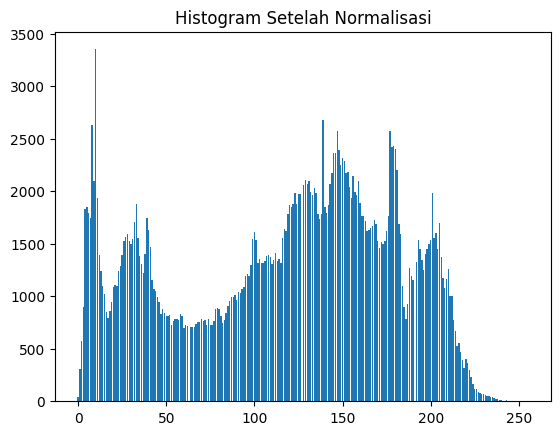

In [106]:
hist_after = np.zeros(256)

for i in range(M):
    for j in range(N):
        intensity = img_norm[i,j]
        hist_after[intensity] += 1

plt.figure()
plt.title("Histogram Setelah Normalisasi")
plt.bar(range(256), hist_after)
plt.show()

Kode tersebut digunakan untuk menghitung dan menampilkan histogram citra setelah proses normalisasi. Array hist_after = np.zeros(256) dibuat untuk menyimpan jumlah piksel pada setiap tingkat intensitas (0–255). Melalui perulangan for, setiap piksel pada citra img_norm diambil nilai intensitasnya lalu jumlahnya ditambahkan ke indeks histogram yang sesuai.

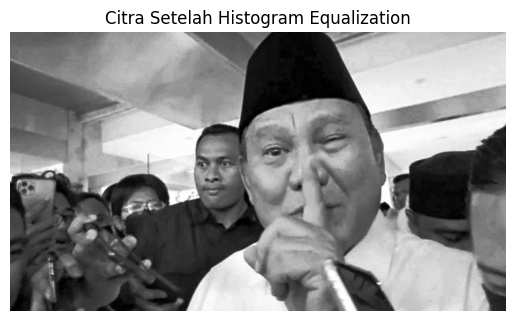

In [108]:
hist = np.zeros(256)

for i in range(M):
    for j in range(N):
        hist[img_norm[i,j]] += 1

# Normalisasi histogram
hist_norm = hist / total_pixel

# CDF (Cumulative Distribution Function)
cdf = np.zeros(256)
cdf[0] = hist_norm[0]

for i in range(1,256):
    cdf[i] = cdf[i-1] + hist_norm[i]

# Mapping intensitas baru
img_equal = np.zeros((M,N), dtype=np.uint8)

for i in range(M):
    for j in range(N):
        new_value = cdf[img_norm[i,j]] * 255

        if new_value > 255:
            new_value = 255
        elif new_value < 0:
            new_value = 0

        img_equal[i,j] = int(new_value)
plt.figure()
plt.imshow(img_equal, cmap='gray')
plt.title("Citra Setelah Histogram Equalization")
plt.axis('off')
plt.show()

Kode tersebut digunakan untuk melakukan proses Histogram Equalization pada citra yang sudah dinormalisasi. Pertama dibuat array hist untuk menghitung histogram dari citra img_norm dengan menghitung jumlah piksel pada setiap intensitas. Setelah itu histogram dinormalisasi dengan membagi jumlah piksel dengan total_pixel sehingga diperoleh probabilitas tiap intensitas (hist_norm). Selanjutnya dihitung CDF (Cumulative Distribution Function) yang merupakan penjumlahan kumulatif dari histogram normalisasi. Nilai CDF ini kemudian digunakan untuk melakukan mapping intensitas baru pada setiap piksel sehingga kontras citra menjadi lebih baik.

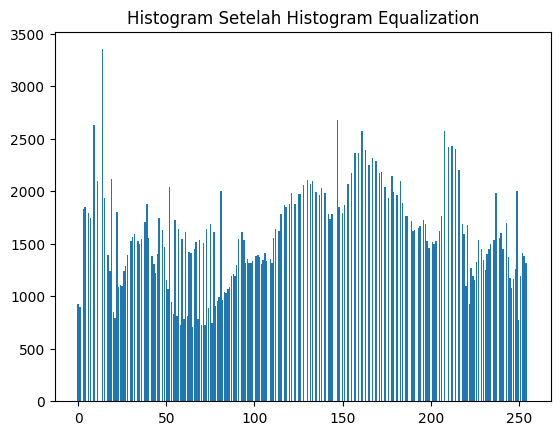

In [109]:
hist_equal = np.zeros(256)

for i in range(M):
    for j in range(N):
        hist_equal[img_equal[i,j]] += 1

plt.figure()
plt.title("Histogram Setelah Histogram Equalization")
plt.bar(range(256), hist_equal)
plt.show()

Kode tersebut digunakan untuk menghitung dan menampilkan histogram citra setelah proses Histogram Equalization. Array hist_equal = np.zeros(256) dibuat untuk menyimpan jumlah piksel pada setiap tingkat intensitas (0–255). Melalui perulangan for, setiap piksel pada citra img_equal diambil nilai intensitasnya lalu jumlahnya ditambahkan ke indeks histogram yang sesuai.

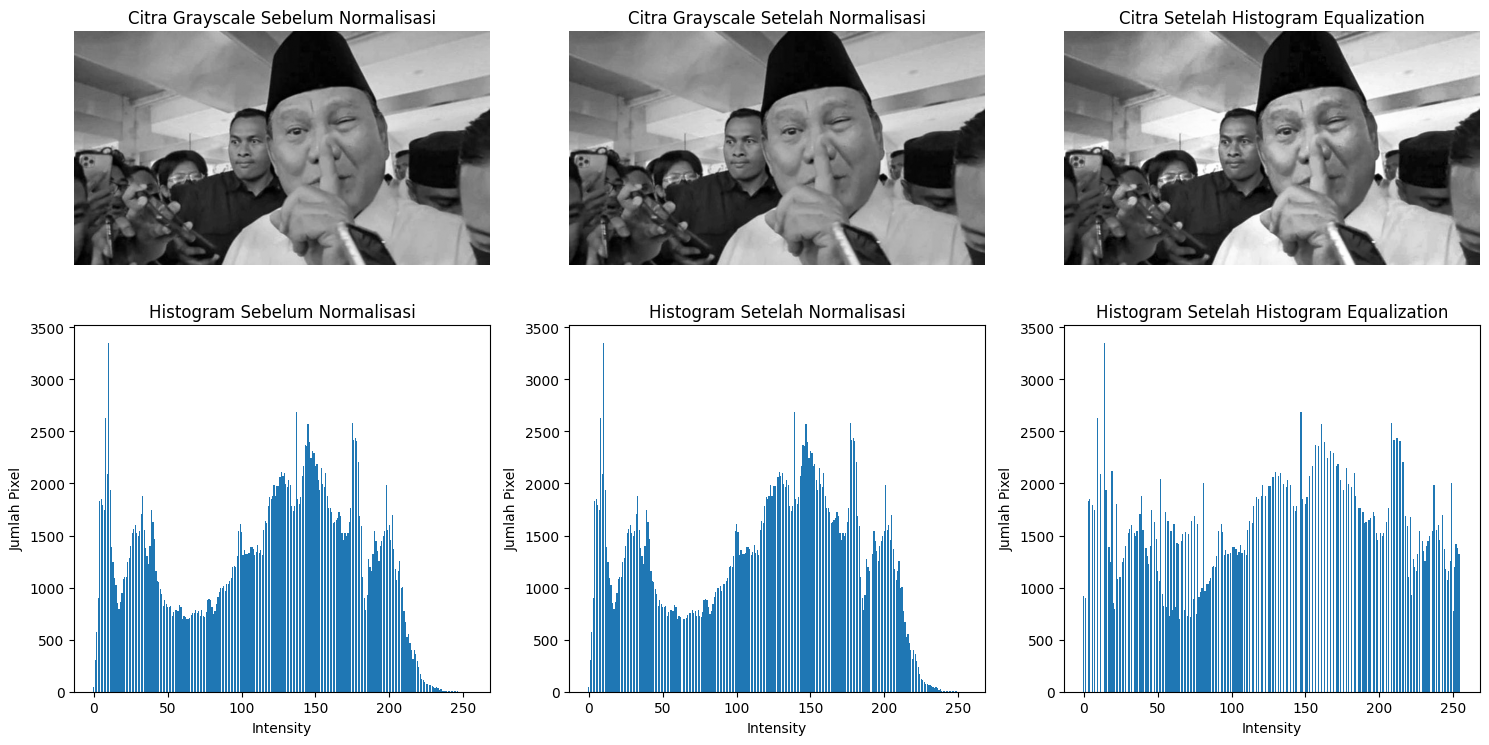

In [110]:
plt.figure(figsize=(15,8))

# 1 Citra Grayscale sebelum normalisasi
plt.subplot(2,3,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Citra Grayscale Sebelum Normalisasi")
plt.axis('off')

# 2 Citra Grayscale setelah normalisasi
plt.subplot(2,3,2)
plt.imshow(img_norm, cmap='gray')
plt.title("Citra Grayscale Setelah Normalisasi")
plt.axis('off')

# 3 Citra setelah Histogram Equalization
plt.subplot(2,3,3)
plt.imshow(img_equal, cmap='gray')
plt.title("Citra Setelah Histogram Equalization")
plt.axis('off')

# 4 Histogram sebelum normalisasi
plt.subplot(2,3,4)
plt.bar(range(256), hist_before)
plt.title("Histogram Sebelum Normalisasi")
plt.xlabel("Intensity")
plt.ylabel("Jumlah Pixel")

# 5 Histogram setelah normalisasi
plt.subplot(2,3,5)
plt.bar(range(256), hist_after)
plt.title("Histogram Setelah Normalisasi")
plt.xlabel("Intensity")
plt.ylabel("Jumlah Pixel")

# 6 Histogram setelah histogram equalization
plt.subplot(2,3,6)
plt.bar(range(256), hist_equal)
plt.title("Histogram Setelah Histogram Equalization")
plt.xlabel("Intensity")
plt.ylabel("Jumlah Pixel")

plt.tight_layout()
plt.show()

Kode tersebut digunakan untuk menampilkan perbandingan citra dan histogram sebelum dan sesudah proses peningkatan kontras dalam satu tampilan. Fungsi plt.figure(figsize=(15,8)) membuat satu kanvas gambar besar, kemudian plt.subplot(2,3,...) membagi tampilan menjadi 2 baris dan 3 kolom. Baris pertama menampilkan citra grayscale sebelum normalisasi, citra setelah normalisasi, dan citra setelah histogram equalization. Baris kedua menampilkan histogram sebelum normalisasi, histogram setelah normalisasi, dan histogram setelah histogram equalization. Perintah plt.tight_layout() digunakan agar jarak antar gambar rapi, lalu plt.show() menampilkan seluruh hasil perbandingan.

Dari visualisasi di atas, kita bisa menginterpretasikannya seperti berikut:
- Citra asli (grayscale) memiliki rentang nilai intensitas antara 0 hingga 251, yang menunjukkan bahwa citra tersebut belum memanfaatkan seluruh daerah derajat keabuan yang tersedia secara penuh. Melalui proses normalisasi, rentang intensitas dipetakan ulang sehingga mencapai nilai maksimal 255, yang secara teori meningkatkan kontras citra karena sebaran terang (lightness) dan gelap (darkness) menjadi lebih luas. Meskipun secara visual citra sebelum dan sesudah normalisasi histogram sering kali terlihat serupa, data statistiknya telah berubah di mana setiap jumlah piksel per intensitas dibagi dengan total seluruh piksel ($n_i/n$) untuk mendapatkan nilai peluang ($h_i$) dalam selang 0 sampai 1.

- Perubahan kualitas visual yang paling signifikan terjadi setelah penerapan Histogram Equalization, di mana distribusi gray level diubah agar lebih menyebar merata pada kisaran 0-255. Dengan memanfaatkan fungsi distribusi kumulatif (CDF), intensitas piksel yang awalnya menumpuk pada area tertentu dijarangkan sehingga histogram baru mengisi daerah derajat keabuan secara penuh dengan distribusi yang lebih seragam. Hasil akhirnya adalah citra dengan kualitas interpretasi yang lebih baik, ditandai dengan detail objek yang lebih tajam dan kontras yang lebih tinggi dibandingkan kondisi awal.